In [ ]:
import sqlite3            
import pandas as pd       
import numpy as np        
import matplotlib.pyplot as plt   

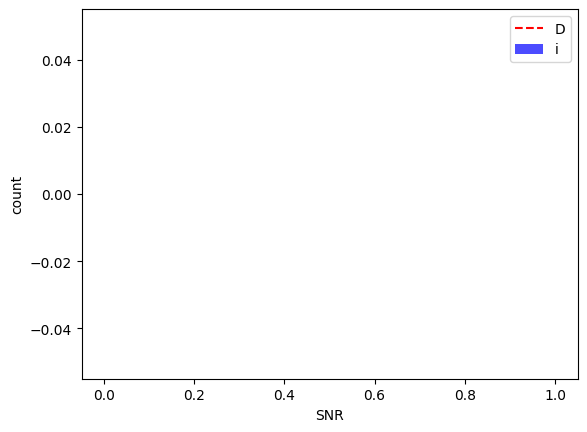

In [4]:
# Get connection to the database
conn = sqlite3.connect('spectra.db')
df   = pd.read_sql_query("SELECT SNR FROM spectra", conn)
conn.close()

#Compute stats
mean = df['SNR'].mean()
std = df['SNR'].std()

#Plotting histogram
plt.hist(df['SNR'], bins=1000, alpha=0.7, color='blue')
plt.axvline(mean-3*std, color='r', linestyle='--',
            label='mean - 3σ')
plt.legend("Distribution of SNR values with mean - 3σ threshold")
plt.xlabel('SNR')
plt.ylabel('count')
plt.show()

In [ ]:
# compute cutoff and filter the dataframe
cutoff = mean - 3*std
print(f"cutoff value: {cutoff}")
# rows to keep
cleaned = df[df['SNR'] > cutoff]

# apply wavelength filter to cleaned dataframe before touching SQL
low, high = 392.366, 397.847
cleaned = cleaned[(cleaned['WAVELMIN'] >= low) & (cleaned['WAVELMAX'] <= high)]
print(f"rows remaining after in-memory wavelength filter: {len(cleaned)}")

# open connection again to remove the others from the SQL table
del_conn = sqlite3.connect('spectra.db')
del_cur = del_conn.cursor()

# delete rows with SNR <= cutoff
sql_delete = "DELETE FROM spectra WHERE SNR <= ?"
del_cur.execute(sql_delete, (cutoff,))

# also delete those outside wavelength range in SQL to keep both in sync
sql_del_wave = "DELETE FROM spectra WHERE WAVELMIN < ? OR WAVELMAX > ?"
del_cur.execute(sql_del_wave, (low, high))

del_conn.commit()

del_conn.close()

print(f"original rows: {len(df)}, remaining after deletion: {len(cleaned)}")


NameError: name 'mean' is not defined

In [ ]:
#